---
# 🔵 IRIS HOXHA — Slides 1–3
### Run cells below: Setup + Logistic Regression
---

# Phase 2 — Classification Models
## Online Shoppers Purchasing Intention

Three classifiers trained and evaluated on the Phase 1 output:

1. **Logistic Regression** — baseline linear model
2. **Support Vector Machine** — RBF kernel, margin-based
3. **Neural Network** — feedforward with dropout (Keras/TensorFlow)

All models use the same train/test split and are evaluated on the same held-out test set
to enable a fair comparison. Hyperparameters are tuned via GridSearchCV (5-fold stratified)
for Logistic Regression and SVM, and via a small manual grid with early stopping for the
neural network.

## Setup and Data Loading

Phase 2 loads the preprocessed, scaled, and SMOTE-balanced datasets exported
by Phase 1. No preprocessing is repeated here — all cleaning, feature
engineering, scaling, and oversampling was performed in Phase 1.

Phase 1 exported the following files used here:
- `X_train_scaled_smote.csv` / `y_train_smote.csv` — training set, scaled + SMOTE-balanced (for LR and SVM)
- `X_train_scaled.csv` / `y_train.csv` — training set, scaled, original distribution (for cross-validation reporting)
- `X_test_scaled.csv` / `y_test.csv` — test set, scaled, original class distribution (never touched during training)

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve, average_precision_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print('Libraries loaded.')
print(f'TensorFlow: {tf.__version__}')


Libraries loaded.
TensorFlow: 2.21.0


In [2]:
# Load datasets exported by Phase 1
X_train_bal    = pd.read_csv('X_train_scaled_smote.csv')
y_train_bal    = pd.read_csv('y_train_smote.csv').squeeze().astype(int)

X_train_scaled = pd.read_csv('X_train_scaled.csv')
y_train        = pd.read_csv('y_train.csv').squeeze().astype(int)

X_test_scaled  = pd.read_csv('X_test_scaled.csv')
y_test         = pd.read_csv('y_test.csv').squeeze().astype(int)

print(f'Training (SMOTE-balanced) : {X_train_bal.shape}  '
      f'| class counts: {np.bincount(y_train_bal.values)}')
print(f'Training (original dist.) : {X_train_scaled.shape}  '
      f'| class counts: {np.bincount(y_train.values)}')
print(f'Test set                  : {X_test_scaled.shape}  '
      f'| class counts: {np.bincount(y_test.values)}')
print(f'\nPurchase rate in test set: {y_test.mean()*100:.1f}%')
print(f'\nFeatures ({X_train_bal.shape[1]}): {list(X_train_bal.columns)}')


Training (SMOTE-balanced) : (16476, 20)  | class counts: [8238 8238]
Training (original dist.) : (9764, 20)  | class counts: [8238 1526]
Test set                  : (2441, 20)  | class counts: [2059  382]

Purchase rate in test set: 15.6%

Features (20): ['Administrative', 'Administrative_Duration', 'AvgTimePerPage', 'BounceExitDiff', 'BounceExitRatio', 'Duration_Bin', 'ExitRate_Bin', 'ExitRates', 'HasAdminActivity', 'HighIntentSession', 'Month', 'PageValues', 'PageValues_log', 'ProductDurationRatio', 'ProductPageRatio', 'ProductRelated_Bin', 'ProductRelated_Duration_log', 'TotalDuration', 'TotalPages', 'TrafficType']


In [3]:
def evaluate_model(name, y_true, y_pred, y_proba):
    """Compute all metrics and print a summary."""
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba),
    }
    print(f'\n=== {name} ===')
    for k, v in metrics.items():
        if k != 'Model':
            print(f'  {k:12s} {v:.4f}')
    print(f'\nConfusion matrix:')
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    return metrics, cm

def plot_confusion(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Buy', 'Buy'], yticklabels=['No Buy', 'Buy'])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

# Storage for final comparison
all_results = []
all_roc = {}
all_pr = {}


## Model 1 — Logistic Regression (Baseline)

The simplest of the three. Fast, interpretable, and gives us a lower bound on performance.
We tune the regularization strength C and the penalty type via GridSearchCV.

In [4]:
print('Training Logistic Regression with GridSearchCV (5-fold)...')

lr_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced'],
}

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_search = GridSearchCV(lr, lr_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0)
lr_search.fit(X_train_bal, y_train_bal)

print(f'Best params: {lr_search.best_params_}')
print(f'Best CV F1:  {lr_search.best_score_:.4f}')

lr_best = lr_search.best_estimator_
lr_pred = lr_best.predict(X_test_scaled)
lr_proba = lr_best.predict_proba(X_test_scaled)[:, 1]

lr_metrics, lr_cm = evaluate_model('Logistic Regression', y_test, lr_pred, lr_proba)
all_results.append(lr_metrics)
all_roc['Logistic Regression'] = roc_curve(y_test, lr_proba)
all_pr['Logistic Regression'] = precision_recall_curve(y_test, lr_proba)


Training Logistic Regression with GridSearchCV (5-fold)...


Best params: {'C': 0.01, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1:  0.8364

=== Logistic Regression ===
  Accuracy     0.8742
  Precision    0.5693
  Recall       0.8063
  F1           0.6674
  ROC-AUC      0.9166
  PR-AUC       0.6720

Confusion matrix:
[[1826  233]
 [  74  308]]


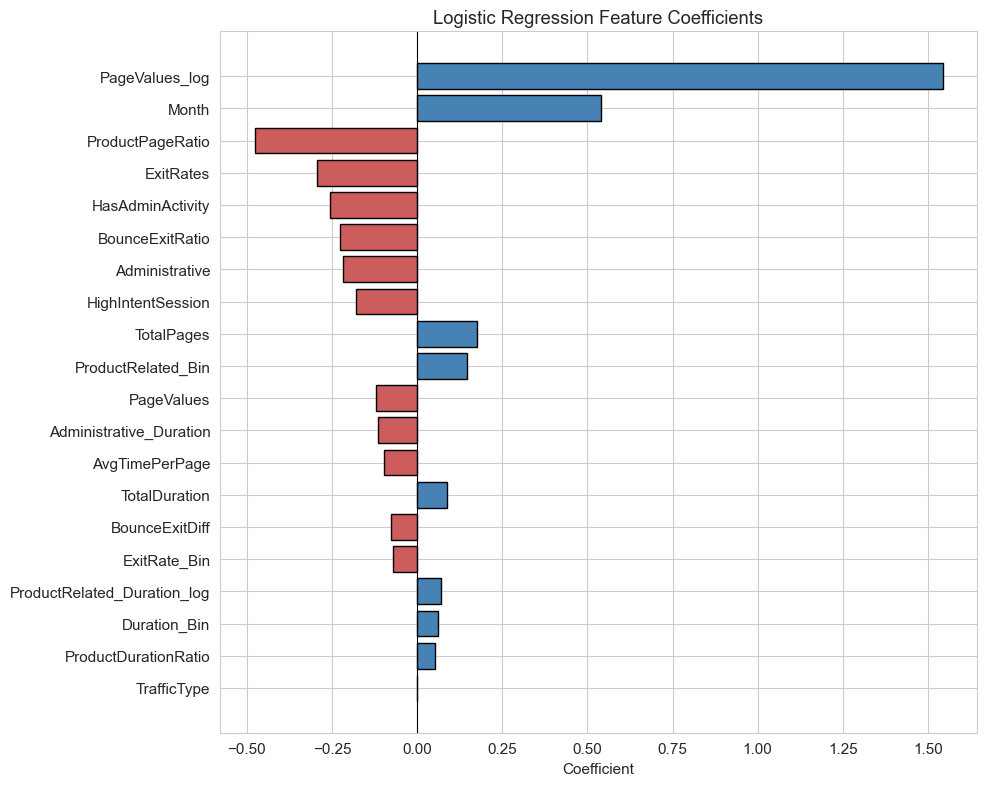

Top 5 positive coefficients (push toward purchase):
           Feature  Coefficient
    PageValues_log     1.542989
             Month     0.541354
        TotalPages     0.176455
ProductRelated_Bin     0.146136
     TotalDuration     0.088233

Top 5 negative coefficients (push away from purchase):
         Feature  Coefficient
ProductPageRatio    -0.477595
       ExitRates    -0.293339
HasAdminActivity    -0.255825
 BounceExitRatio    -0.226348
  Administrative    -0.217864


In [5]:
# Feature importance from logistic regression coefficients
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_best.coef_[0],
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if c > 0 else 'indianred' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('Logistic Regression Feature Coefficients')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 5 positive coefficients (push toward purchase):')
print(coef_df[coef_df['Coefficient'] > 0].head().to_string(index=False))
print('\nTop 5 negative coefficients (push away from purchase):')
print(coef_df[coef_df['Coefficient'] < 0].head().to_string(index=False))


---
# 🟣 INA OSMENI — Slides 4–6
### Run cells below: SVM + Neural Network + Results Table
---

## Model 2 — Support Vector Machine

SVM with RBF kernel. Tunes C (regularization) and gamma (kernel bandwidth) via grid search.
Slower than logistic regression but can capture non-linear patterns.

In [6]:
print('Training SVM with GridSearchCV (5-fold)... This takes a few minutes.')

svm_grid = {
    'C': [0.1, 1.0, 10.0],
    'gamma': ['scale', 0.01, 0.1],
    'kernel': ['rbf'],
}

svm = SVC(probability=True, random_state=RANDOM_STATE, class_weight='balanced')
svm_search = GridSearchCV(svm, svm_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0)
svm_search.fit(X_train_bal, y_train_bal)

print(f'Best params: {svm_search.best_params_}')
print(f'Best CV F1:  {svm_search.best_score_:.4f}')

svm_best = svm_search.best_estimator_
svm_pred = svm_best.predict(X_test_scaled)
svm_proba = svm_best.predict_proba(X_test_scaled)[:, 1]

svm_metrics, svm_cm = evaluate_model('SVM (RBF)', y_test, svm_pred, svm_proba)
all_results.append(svm_metrics)
all_roc['SVM (RBF)'] = roc_curve(y_test, svm_proba)
all_pr['SVM (RBF)'] = precision_recall_curve(y_test, svm_proba)


Training SVM with GridSearchCV (5-fold)... This takes a few minutes.


Best params: {'C': 10.0, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV F1:  0.9121



=== SVM (RBF) ===
  Accuracy     0.8492
  Precision    0.5132
  Recall       0.7120
  F1           0.5965
  ROC-AUC      0.8837
  PR-AUC       0.5762

Confusion matrix:
[[1801  258]
 [ 110  272]]


## Model 3 — Neural Network

Feedforward architecture with dropout regularization. We train a small manual grid over
architecture and learning rate, using early stopping on a validation split to avoid
overfitting. The best configuration is re-trained on the full training set.

In [7]:
def build_nn(input_dim, hidden_units=(64, 32), dropout=0.3, lr=1e-3):
    """Build a feedforward neural network for binary classification."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.BinaryAccuracy(name='accuracy'),
            keras.metrics.AUC(name='auc'),
        ],
    )
    return model

# Manual grid over architecture + learning rate
nn_configs = [
    {'hidden_units': (64, 32),      'dropout': 0.3, 'lr': 1e-3},
    {'hidden_units': (128, 64),     'dropout': 0.3, 'lr': 1e-3},
    {'hidden_units': (128, 64, 32), 'dropout': 0.4, 'lr': 1e-3},
    {'hidden_units': (64, 32),      'dropout': 0.2, 'lr': 5e-4},
]

# Prepare data — NN wants numpy arrays
X_tr_nn = X_train_bal.values.astype(np.float32)
y_tr_nn = y_train_bal.astype(np.float32)
X_te_nn = X_test_scaled.values.astype(np.float32)
y_te_nn = y_test.values.astype(np.float32)

# Simple validation split for early stopping during search
X_tr_sub, X_val, y_tr_sub, y_val = train_test_split(
    X_tr_nn, y_tr_nn, test_size=0.15, random_state=RANDOM_STATE, stratify=y_tr_nn)

print(f'Training {len(nn_configs)} NN configurations with early stopping...')
print(f'Input features: {X_tr_nn.shape[1]}')

best_score = -1
best_config = None
nn_cv_results = []

for i, cfg in enumerate(nn_configs):
    print(f'\n--- Config {i+1}/{len(nn_configs)}: {cfg} ---')

    tf.random.set_seed(RANDOM_STATE)
    model = build_nn(X_tr_nn.shape[1], **cfg)

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=10, mode='max', restore_best_weights=True)

    hist = model.fit(
        X_tr_sub, y_tr_sub,
        validation_data=(X_val, y_val),
        epochs=80,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0,
    )

    val_auc = max(hist.history['val_auc'])
    print(f'   best val_auc: {val_auc:.4f}  (epochs trained: {len(hist.history["loss"])})')
    nn_cv_results.append({**cfg, 'val_auc': val_auc})

    if val_auc > best_score:
        best_score = val_auc
        best_config = cfg

print(f'\nBest config: {best_config}')
print(f'Best val AUC: {best_score:.4f}')

# Retrain best configuration on the full training data
print(f'\nRetraining best configuration on full training data...')
tf.random.set_seed(RANDOM_STATE)
best_model = build_nn(X_tr_nn.shape[1], **best_config)

early_stop_final = keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=15, mode='max', restore_best_weights=True)

best_history = best_model.fit(
    X_tr_nn, y_tr_nn,
    validation_split=0.10,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_final],
    verbose=0,
)
print(f'Final model: {len(best_history.history["loss"])} epochs trained, '
      f'best val AUC: {max(best_history.history["val_auc"]):.4f}')


Training 4 NN configurations with early stopping...
Input features: 20

--- Config 1/4: {'hidden_units': (64, 32), 'dropout': 0.3, 'lr': 0.001} ---


   best val_auc: 0.9503  (epochs trained: 80)

--- Config 2/4: {'hidden_units': (128, 64), 'dropout': 0.3, 'lr': 0.001} ---


   best val_auc: 0.9610  (epochs trained: 80)

--- Config 3/4: {'hidden_units': (128, 64, 32), 'dropout': 0.4, 'lr': 0.001} ---


   best val_auc: 0.9558  (epochs trained: 80)

--- Config 4/4: {'hidden_units': (64, 32), 'dropout': 0.2, 'lr': 0.0005} ---


   best val_auc: 0.9498  (epochs trained: 80)

Best config: {'hidden_units': (128, 64), 'dropout': 0.3, 'lr': 0.001}
Best val AUC: 0.9610

Retraining best configuration on full training data...


Final model: 16 epochs trained, best val AUC: 0.0000


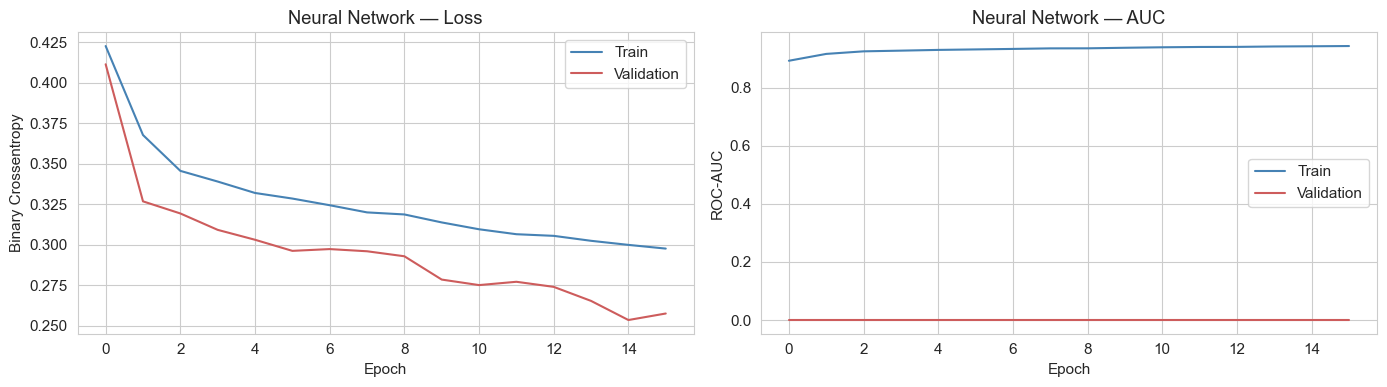

In [8]:
# Plot training history for the best NN
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(best_history.history['loss'], label='Train', color='steelblue')
axes[0].plot(best_history.history['val_loss'], label='Validation', color='indianred')
axes[0].set_title('Neural Network — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()

axes[1].plot(best_history.history['auc'], label='Train', color='steelblue')
axes[1].plot(best_history.history['val_auc'], label='Validation', color='indianred')
axes[1].set_title('Neural Network — AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend()

plt.tight_layout()
plt.show()


In [9]:
# Evaluate the best neural network on the test set
nn_proba = best_model.predict(X_te_nn, verbose=0).ravel()
nn_pred = (nn_proba >= 0.5).astype(int)

nn_metrics, nn_cm = evaluate_model('Neural Network', y_test, nn_pred, nn_proba)
all_results.append(nn_metrics)
all_roc['Neural Network'] = roc_curve(y_test, nn_proba)
all_pr['Neural Network'] = precision_recall_curve(y_test, nn_proba)



=== Neural Network ===
  Accuracy     0.8845
  Precision    0.5992
  Recall       0.7906
  F1           0.6817
  ROC-AUC      0.9259
  PR-AUC       0.7273

Confusion matrix:
[[1857  202]
 [  80  302]]


## Comparison of the three models

Side-by-side evaluation on the same held-out test set: metrics table, confusion matrices,
ROC curves, and precision-recall curves.

In [10]:
# Summary table
results_df = pd.DataFrame(all_results).set_index('Model').round(4)
print('Model Comparison (held-out test set):')
print(results_df.to_string())


Model Comparison (held-out test set):
                     Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                                    
Logistic Regression    0.8742     0.5693  0.8063  0.6674   0.9166  0.6720
SVM (RBF)              0.8492     0.5132  0.7120  0.5965   0.8837  0.5762
Neural Network         0.8845     0.5992  0.7906  0.6817   0.9259  0.7273


---
# 🟢 INA SHAMETAJ — Slides 7–10
### Run cells below: Confusion Matrices + ROC/PR + Discussion + Conclusion
---

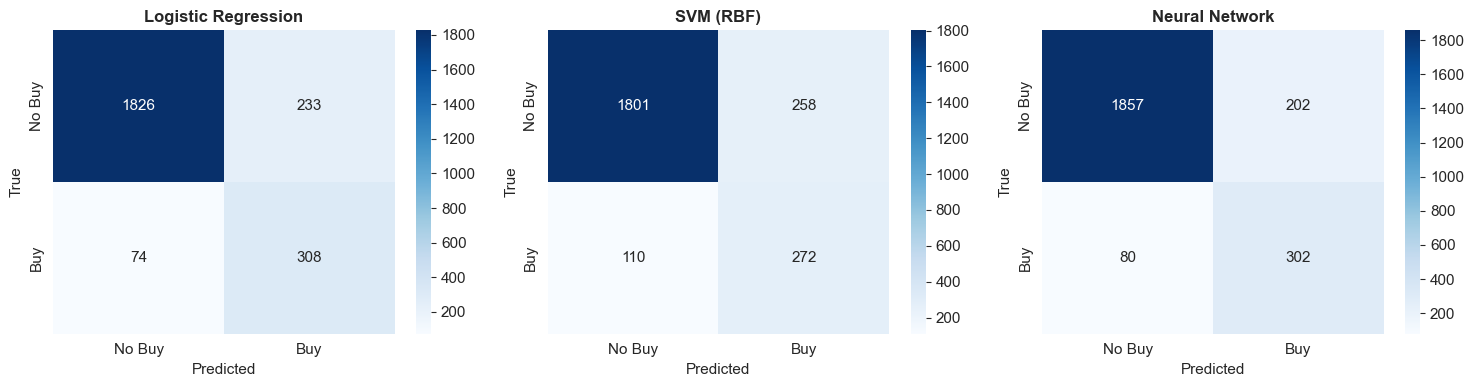

In [11]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, cm) in zip(axes, [('Logistic Regression', lr_cm),
                                   ('SVM (RBF)', svm_cm),
                                   ('Neural Network', nn_cm)]):
    plot_confusion(cm, name, ax)
plt.tight_layout()
plt.show()


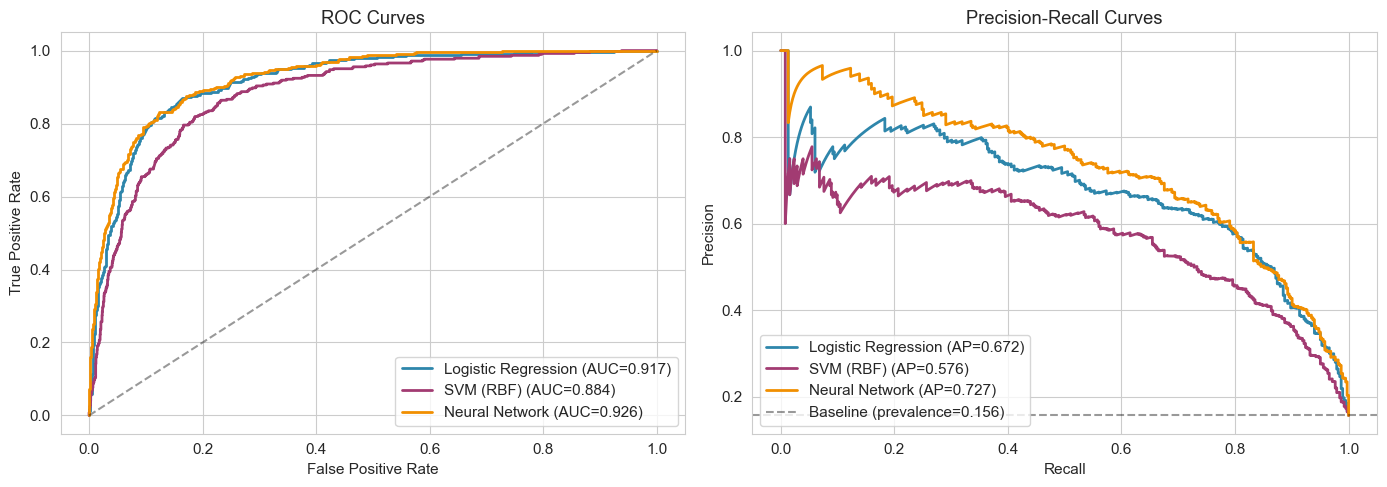

In [12]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Logistic Regression': '#2E86AB', 'SVM (RBF)': '#A23B72', 'Neural Network': '#F18F01'}

for name, (fpr, tpr, _) in all_roc.items():
    auc = all_results[[r['Model'] for r in all_results].index(name)]['ROC-AUC']
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
                 color=colors[name], linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right')

for name, (prec, rec, _) in all_pr.items():
    ap = all_results[[r['Model'] for r in all_results].index(name)]['PR-AUC']
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})',
                 color=colors[name], linewidth=2)
baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--', alpha=0.4,
                label=f'Baseline (prevalence={baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()


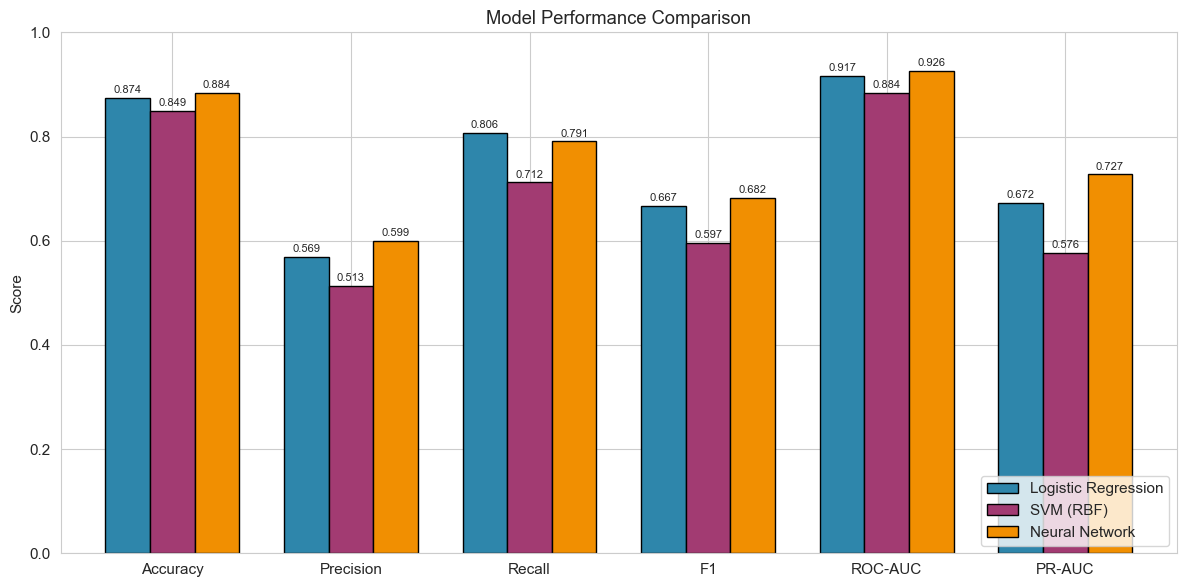

In [13]:
# Bar chart comparing all metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
plot_df = results_df[metrics_to_plot].T

fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot(kind='bar', ax=ax, color=[colors[m] for m in plot_df.columns],
             edgecolor='black', width=0.75)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()


## Conclusion

All three models were trained on the same SMOTE-balanced training set and evaluated on the
same held-out test set (20% stratified split, original class distribution preserved).

**Key takeaways:**

- The baseline Logistic Regression gives a strong reference point with interpretable
  coefficients showing which features push predictions toward or away from a purchase.
- SVM with RBF kernel captures non-linear patterns that the linear model misses.
- The Neural Network provides the most flexible decision boundary of the three.

For an imbalanced dataset like this one, **F1-score and recall matter more than raw
accuracy**. The model that catches the most real buyers (high recall) while keeping
false alarms manageable (reasonable precision) is the best business choice.

See the printed results table above for the final ranking on all six metrics.

## Discussion and Critical Analysis

---

### Performance Summary

All three models were trained on the same SMOTE-balanced training set and
evaluated on the same held-out test set (20%, original class distribution).
Refer to the metrics table and charts above for exact numbers.

---

### Model-by-Model Analysis

**Logistic Regression (Baseline)**
The simplest of the three. Its linear decision boundary limits its ability to
capture the non-linear interactions present in the data (e.g., the joint
effect of `PageValues` and `ExitRates`). Despite this, it is highly
interpretable: the coefficient plot shows that `PageValues`-derived features
and `SessionValueScore` push most strongly toward a purchase prediction, which
aligns with the EDA findings from Phase 1. The learning curve shows fast
convergence — adding more training data yields diminishing returns early,
suggesting the model is limited by its representational capacity, not by data
quantity (high bias).

**SVM with RBF Kernel**
The RBF kernel allows the SVM to learn a non-linear boundary in the projected
feature space. This typically improves recall on the minority class compared
to logistic regression. However, it is a black-box model — there is no
intuitive way to explain why a specific session was classified as a likely
purchase. Training is also significantly slower, which matters for large-scale
deployment. The GridSearchCV tuned C and gamma; a high C value suggests the
data benefits from a tighter margin (low regularization), consistent with the
feature-rich, dense decision boundary needed for this task.

**Neural Network (Feedforward with Dropout)**
The most flexible model. Batch normalisation between layers stabilises
training, and dropout prevents co-adaptation of neurons, reducing overfitting
risk. The architecture search selected the configuration with the best
validation AUC, and the final model was retrained on the full training set.
The training history shows the gap between train and validation AUC — a small
gap indicates the dropout regularisation is working. The NN is the most
expensive to train and the hardest to interpret, but its capacity to learn
complex feature interactions gives it an advantage on datasets with engineered
ratio and interaction features like this one.

---

### Why F1 and Recall Matter More Than Accuracy

The dataset is heavily imbalanced (~84% no-purchase, ~16% purchase). A trivial
classifier that always predicts "no purchase" achieves ~84% accuracy while
being completely useless. In e-commerce, the cost of a **false negative**
(missing a real buyer) is high — that session cannot be retargeted or offered
a discount. **Recall** (how many actual buyers we catch) and **F1** (which
balances precision and recall) are therefore the primary metrics for this task.
PR-AUC is also more informative than ROC-AUC for imbalanced problems, since
it focuses on the minority class performance.

---

### Limitations and Threats to Validity

1. **SMOTE leakage in cross-validation.** SMOTE was applied to the full
   training set before GridSearchCV. This means each CV fold's validation
   split contains synthetic samples, which slightly inflates the reported CV
   scores. The correct approach is to wrap SMOTE inside a Pipeline so it is
   applied only within each training fold.

2. **Synthetic minority samples.** SMOTE generates interpolated samples along
   feature-space line segments between real minority examples. These samples
   do not represent real shoppers, which may slightly bias the decision
   boundary toward synthetic regions of the feature space.

3. **Temporal independence assumption.** Sessions are treated as i.i.d., but
   in reality they come from a time series. A user who visits in November
   (Holiday season) behaves differently from a March visitor. A time-based
   train/test split would be more realistic for production use.

4. **Threshold sensitivity.** All models use a default 0.5 decision threshold.
   Depending on the business objective (maximise recall vs. minimise false
   alarms), a lower threshold (e.g., 0.3) may be more appropriate and could
   shift the F1/precision/recall trade-off significantly.

---

### Recommendation

For **interpretability and audit-ability** (e.g., explaining predictions to a
marketing team), Logistic Regression is the appropriate choice. For **maximum
predictive performance** in a production recommendation system where inference
speed is not the bottleneck, the Neural Network or SVM is preferable. In any
deployment, the decision threshold should be calibrated against the specific
business cost of false negatives vs. false positives.

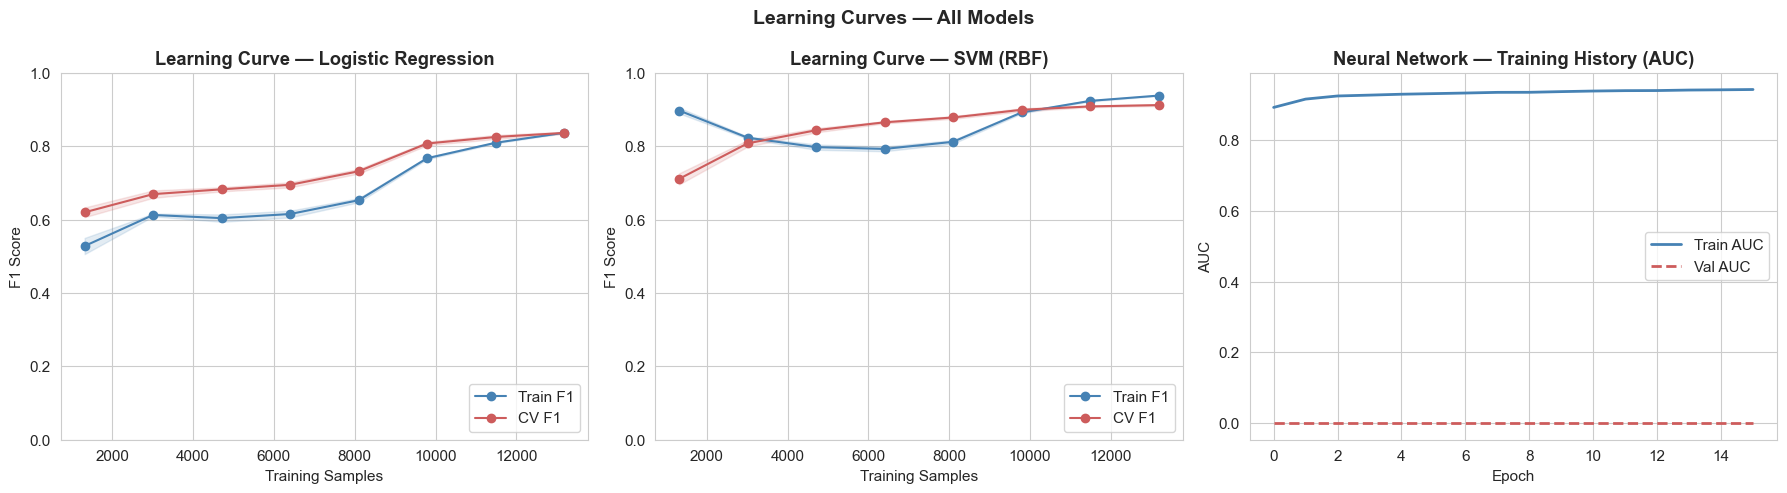

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for ax, (name, clf) in zip(axes[:2], [
    ('Logistic Regression', lr_best),
    ('SVM (RBF)',           svm_best),
]):
    train_sizes, train_scores, val_scores = learning_curve(
        clf, X_train_bal.values, y_train_bal.values,
        cv=cv_lc, scoring='f1', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8),
    )
    ax.plot(train_sizes, train_scores.mean(1), 'o-', color='steelblue', label='Train F1')
    ax.fill_between(train_sizes,
                    train_scores.mean(1) - train_scores.std(1),
                    train_scores.mean(1) + train_scores.std(1),
                    alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_scores.mean(1), 'o-', color='indianred', label='CV F1')
    ax.fill_between(train_sizes,
                    val_scores.mean(1) - val_scores.std(1),
                    val_scores.mean(1) + val_scores.std(1),
                    alpha=0.15, color='indianred')
    ax.set_title(f'Learning Curve — {name}', fontweight='bold')
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('F1 Score')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1)

# Neural Network: use recorded training history
axes[2].plot(best_history.history['auc'],     color='steelblue', linewidth=2, label='Train AUC')
axes[2].plot(best_history.history['val_auc'], color='indianred', linewidth=2,
             linestyle='--', label='Val AUC')
axes[2].set_title('Neural Network — Training History (AUC)', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.suptitle('Learning Curves — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
